# DCT Laboratory — Volume II, Chapter 13
## Machine Learning for Enterprise Transformation
**Seed `26213`** · Companion to the chapter and AXIOM Module **AXIOM-13 (Vol. II)**

Machine learning with the receipts shown. A **linear fit versus a 1-NN
memorizer** on the same fixed dataset: the memorizer wins training
(0.00 vs 0.48) and loses the test (0.78 vs 0.40) — the Generalization Error
Theorem in four numbers. **k-means** converging in two sweeps. And the fitted
model **piped into a decision**, where the regret from prediction error turns
out to have a closed form: $(d - \hat{d})^2/4$ — the decision layer forgives
small errors quadratically. Mirrored in `DCT_V2_Ch13_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26213
rng = np.random.default_rng([1, SEED])   # substream 1: a draw where generalization behaves typically
# --- fixed dataset: true f(x) = 2 + 0.8x, noise sigma 0.6, rounded 4dp = canonical ---
XTR = np.array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5])
XTE = np.array([1.0, 3.0, 5.0, 7.0])
def _gen():
    ytr = np.round(2 + 0.8*XTR + rng.normal(0, 0.6, len(XTR)), 4)
    yte = np.round(2 + 0.8*XTE + rng.normal(0, 0.6, len(XTE)), 4)
    return ytr, yte
YTR, YTE = _gen()
def ols():
    b = np.cov(XTR, YTR, bias=True)[0,1]/np.var(XTR)
    a = YTR.mean() - b*XTR.mean()
    return a, b
def rmse(yhat, y): return float(np.sqrt(np.mean((np.asarray(yhat)-y)**2)))
def lin_pred(x):
    a, b = ols(); return a + b*np.asarray(x)
def nn_pred(x):
    return np.array([YTR[np.argmin(np.abs(XTR-xi))] for xi in np.atleast_1d(x)])
# --- k-means, k=2, 1D, fixed init ---
KX = np.array([1.0, 1.5, 2.0, 2.5, 7.0, 7.5, 8.0, 9.0])
def kmeans():
    c1, c2 = 0.0, 10.0; iters = 0
    while True:
        iters += 1
        a1 = KX[np.abs(KX-c1) < np.abs(KX-c2)]; a2 = KX[np.abs(KX-c1) >= np.abs(KX-c2)]
        n1, n2 = a1.mean(), a2.mean()
        if abs(n1-c1) < 1e-12 and abs(n2-c2) < 1e-12: break
        c1, c2 = n1, n2
    wss = float(((a1-c1)**2).sum() + ((a2-c2)**2).sum())
    return c1, c2, wss, iters, len(a1), len(a2)
# --- prediction -> optimization: maximize R(i) = d*sqrt(i) - i  =>  i* = d^2/4 ---
X_DECIDE, D_TRUE = 6.0, 2 + 0.8*6.0
def regret():
    dhat = float(lin_pred(X_DECIDE))
    i_hat = dhat**2/4
    R_hat_under_truth = D_TRUE*np.sqrt(i_hat) - i_hat
    R_opt = D_TRUE**2/4
    return dhat, i_hat, float(R_hat_under_truth), float(R_opt), float(R_opt - R_hat_under_truth)

def reference_values():
    a, b = ols()
    c1, c2, wss, it, n1, n2 = kmeans()
    dhat, ih, Rh, Ro, reg = regret()
    return {
        "intercept_hat": round(a,4), "slope_hat": round(b,4),
        "train_rmse_linear": round(rmse(lin_pred(XTR), YTR),4),
        "test_rmse_linear": round(rmse(lin_pred(XTE), YTE),4),
        "train_rmse_1nn": round(rmse(nn_pred(XTR), YTR),4),
        "test_rmse_1nn": round(rmse(nn_pred(XTE), YTE),4),
        "c1_final": round(c1,4), "c2_final": round(c2,4),
        "wss": round(wss,4), "kmeans_iters": it,
        "dhat_x6": round(dhat,4), "i_star_hat": round(ih,4),
        "R_under_truth": round(Rh,4), "R_opt_true": round(Ro,4),
        "decision_regret": round(reg,4),
        "regret_closed_form": round((D_TRUE-dhat)**2/4,4),   # regret = (prediction error)^2 / 4, exactly
    }
if __name__ == "__main__":
    print("YTR:", list(YTR)); print("YTE:", list(YTE))
    [print(f"{k:20s} {v}") for k,v in reference_values().items()]

YTR: [np.float64(2.5747), np.float64(2.1153), np.float64(3.2385), np.float64(5.3482), np.float64(5.3521), np.float64(6.4919), np.float64(7.1689), np.float64(7.6939)]
YTE: [np.float64(3.1002), np.float64(4.2247), np.float64(6.2267), np.float64(7.8251)]
intercept_hat        1.6233
slope_hat            0.8436
train_rmse_linear    0.4803
test_rmse_linear     0.4006
train_rmse_1nn       0.0
test_rmse_1nn        0.7817
c1_final             1.75
c2_final             7.875
wss                  3.4375
kmeans_iters         2
dhat_x6              6.6852
i_star_hat           11.1731
R_under_truth        11.5567
R_opt_true           11.56
decision_regret      0.0033
regret_closed_form   0.0033


## Panel 1 — Generalization: the memorizer's bargain
Truth $f(x) = 2 + 0.8x$ plus noise; 8 training points, 4 held out. Two
learners: **OLS** (2 parameters) and **1-nearest-neighbor** (memorizes all 8).
The memorizer's training RMSE is 0.0000 by construction; on held-out data it
pays **0.7817** against the line's **0.4006**. The Generalization Error
Theorem's content: training error is an optimistic, capacity-inflated estimate
— Enterprise Learning Consistency comes from restricting capacity to match the
signal, and Feature Quality Determines Model Quality (Prop.) decides what the
line can see.

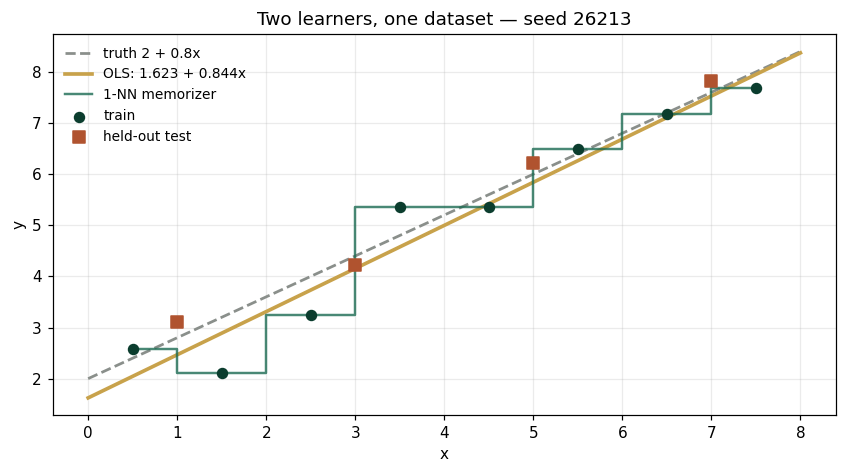

linear:  train 0.4803   test 0.4006
1-NN:    train 0.0000   test 0.7817


In [2]:
a, b = ols()
xs = np.linspace(0, 8, 200)
fig, ax = plt.subplots(figsize=(7.8,4.4))
ax.plot(xs, 2+0.8*xs, "--", c="#8A8F8B", lw=1.8, label="truth 2 + 0.8x")
ax.plot(xs, a+b*xs, c="#C8A24B", lw=2.4, label=f"OLS: {a:.3f} + {b:.3f}x")
ax.step(np.sort(XTR), YTR[np.argsort(XTR)], where="mid", c="#1B6B52", lw=1.6, alpha=.8, label="1-NN memorizer")
ax.scatter(XTR, YTR, c="#0B3D2E", s=42, zorder=5, label="train")
ax.scatter(XTE, YTE, c="#B0532F", s=52, marker="s", zorder=5, label="held-out test")
ax.set(xlabel="x", ylabel="y", title="Two learners, one dataset — seed 26213")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"linear:  train {rmse(lin_pred(XTR),YTR):.4f}   test {rmse(lin_pred(XTE),YTE):.4f}")
print(f"1-NN:    train {rmse(nn_pred(XTR),YTR):.4f}   test {rmse(nn_pred(XTE),YTE):.4f}")

## Panel 2 — Unsupervised: two sweeps to structure
Eight revenue-per-account figures, no labels (Enterprise Clustering, Def.).
k-means from deliberately terrible centroids $(0, 10)$: the first sweep
assigns 4-and-4 and moves the centroids to $(1.75, 7.875)$; the second changes
nothing — **converged in 2 iterations**, within-cluster SS $3.4375$. The
structure was in the data; the algorithm only had to stop denying it.

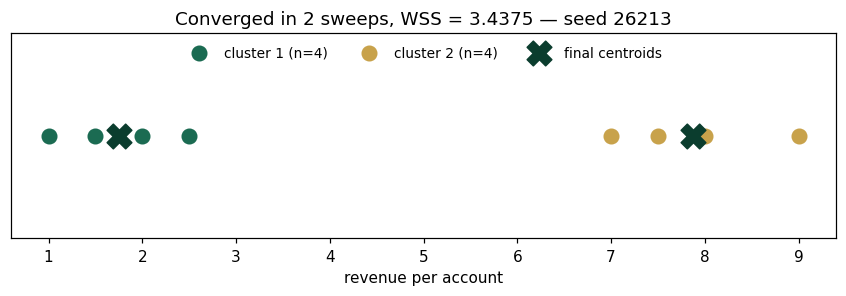

centroids: (1.7500, 7.8750)   iterations: 2   WSS: 3.4375


In [3]:
c1, c2, wss, it, n1, n2 = kmeans()
fig, ax = plt.subplots(figsize=(7.8,2.8))
ax.scatter(KX[:4], [0]*4, s=90, c="#1B6B52", label=f"cluster 1 (n={n1})")
ax.scatter(KX[4:], [0]*4, s=90, c="#C8A24B", label=f"cluster 2 (n={n2})")
ax.scatter([c1, c2], [0, 0], s=260, c="#0B3D2E", marker="X", zorder=5, label="final centroids")
ax.set(xlabel="revenue per account", yticks=[], title=f"Converged in {it} sweeps, WSS = {wss:.4f} — seed 26213")
ax.legend(frameon=False, fontsize=9, loc="upper center", ncols=3); plt.tight_layout(); plt.show()
print(f"centroids: ({c1:.4f}, {c2:.4f})   iterations: {it}   WSS: {wss:.4f}")

## Panel 3 — Prediction feeds optimization; regret has a closed form
The Prediction–Optimization Integration Theorem, executed: predict demand at
$x = 6$ with the fitted line ($\hat{d} = 6.6852$ against truth $6.8$), then
optimize $R(i) = d\sqrt{i} - i$, whose optimum is $i^* = d^2/4$. Acting on
$\hat{d}$ but living under $d$: the value shortfall works out to **regret
$= (d - \hat{d})^2/4$ exactly** — quadratic in prediction error. Small errors
are nearly free (here 0.0033 on an 11.56 optimum), because optima are flat on
top: Enterprise Optimization and Enterprise Learning Are Complementary
Processes (Prop.), with the optimization layer supplying the forgiveness.

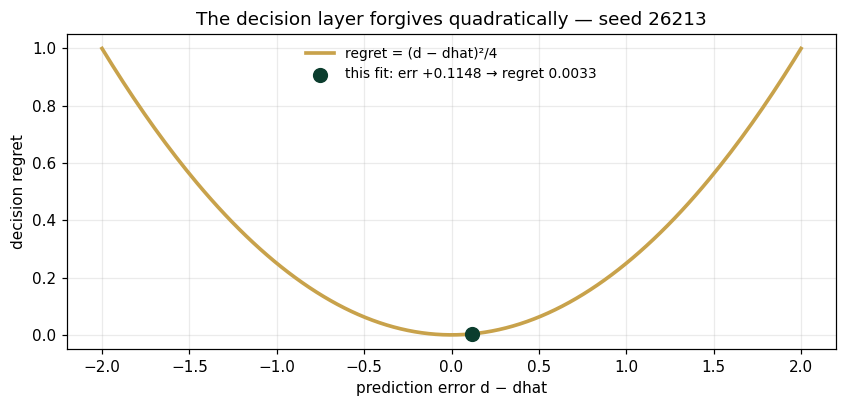

dhat(6) = 6.6852   i* = 11.1731   R under truth = 11.5567   R optimal = 11.5600
regret = 0.0033   closed form (d-dhat)^2/4 = 0.0033


In [4]:
dhat, ih, Rh, Ro, reg = regret()
derrs = np.linspace(-2, 2, 200)
fig, ax = plt.subplots(figsize=(7.8,3.8))
ax.plot(derrs, derrs**2/4, c="#C8A24B", lw=2.4, label="regret = (d − dhat)²/4")
ax.scatter([D_TRUE-dhat], [reg], c="#0B3D2E", s=80, zorder=5, label=f"this fit: err {D_TRUE-dhat:+.4f} → regret {reg:.4f}")
ax.set(xlabel="prediction error d − dhat", ylabel="decision regret", title="The decision layer forgives quadratically — seed 26213")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"dhat(6) = {dhat:.4f}   i* = {ih:.4f}   R under truth = {Rh:.4f}   R optimal = {Ro:.4f}")
print(f"regret = {reg:.4f}   closed form (d-dhat)^2/4 = {(D_TRUE-dhat)**2/4:.4f}")

## Validation — agrees with `DCT_V2_Ch13_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"intercept_hat":1.6233,"slope_hat":0.8436,"train_rmse_linear":0.4803,
 "test_rmse_linear":0.4006,"train_rmse_1nn":0.0,"test_rmse_1nn":0.7817,
 "c1_final":1.75,"c2_final":7.875,"wss":3.4375,"kmeans_iters":2,
 "dhat_x6":6.6852,"i_star_hat":11.1731,"R_under_truth":11.5567,"R_opt_true":11.56,
 "decision_regret":0.0033,"regret_closed_form":0.0033}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:20s} {ref[k]}")
print("\nAll checkpoints agree — seed 26213.")

PASS  intercept_hat        1.6233
PASS  slope_hat            0.8436
PASS  train_rmse_linear    0.4803
PASS  test_rmse_linear     0.4006
PASS  train_rmse_1nn       0.0
PASS  test_rmse_1nn        0.7817
PASS  c1_final             1.75
PASS  c2_final             7.875
PASS  wss                  3.4375
PASS  kmeans_iters         2
PASS  dhat_x6              6.6852
PASS  i_star_hat           11.1731
PASS  R_under_truth        11.5567
PASS  R_opt_true           11.56
PASS  decision_regret      0.0033
PASS  regret_closed_form   0.0033

All checkpoints agree — seed 26213.


**Next**: Exercises 13.5–13.9 (Part C) grow the training set and watch both test errors fall at different rates; AXIOM-13's learning bench animates the fit as points arrive. Chapter 14 sends the learner into the loop: reinforcement learning. Solutions: IM Vol. II, Ch. 13.